In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 7** - Optimizing an ML model with 6 hyperparameters

- This function is about optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers.

- The function you’re **maximising** is the **model’s performance score** (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function.

- This week I will be basing my initial model based on random search and a stratgic model.
  - The straegic model will have an GP regressor and acquisition function.
    - I aim to base the parameters by researching best practices or literature to guide your initial search space.
- **Goal** - find the combination of hyperparameters that yields the highest possible performance.

- **Input** - 6D (30,6)
- **Output** - 6D (30,)

- **Goal** - Maximisation

In [2]:
X = np.load('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy')
Y = np.load('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy')

In [3]:
# New data from Week 3 (Function 7)
X_w3_new_point = np.array([0.017847, 0.815326, 0.270978, 0.212167, 0.499065, 0.497593], dtype=np.float64)
Y_w3_new_point = np.array([0.2579112777248627], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w3_new_point.reshape(1, -1)))
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)
Y_updated = np.append(Y, Y_w3_new_point)[unique_indices]

# Save the updated arrays
np.save('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy', X_unique)
np.save('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy', Y_updated)

In [4]:
# Show updated arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.001234   0.887611   0.445322   0.221098   0.990123   0.556712  ]
 [0.017847   0.815326   0.270978   0.212167   0.499065   0.497593  ]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.06661051 0.52804507 0.8160952  0.96101714 0.08650933 0.77778822]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.14864702 0.03394336 0.72880565 0.31606646 0.02176938 0.51691776]
 [0.17597754 0.6244165  0.29554198 0.46955276 0.09776977 0.72814108]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.22634792 0.11502581 0.82474966 0.94538372 0.90531153 0.95101392]
 [0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.31981043 0.52009759 0.29067775 0.87670668 0.49503469 0.6190825 ]
 [0.41762629 0.06409998 0.24566877 0.5590408  0.19153138 0.25464092]


### **Interpretation of the Output**

- The output of $0.2579$ is a modest score. 
    - In a 6D context (like complex climate modeling or multi-stage chemical synthesis), this value suggests I am in a safe region of the parameter space, but nowhere near the global optimum.

- In 6D, the "volume" expands so rapidly that the Gaussian Process will default to a flat prediction almost everywhere. 
    - This is where the model is most likely to "give up" and return a constant value.
    
- I need to find which variables are the most effective out of your 6 variables, it's statistically likely that only 2 or 3 are actually driving the output. 
    - We need to find which ones they are.

### **Bayesian Optimisation** - Gaussian Optimisation
I am making 3 changes:
- `Matern(nu=2.5)` + `WhiteKernel`
    - We use Matern because RBF is "too smooth" and can miss sharp 6D ridges. 
    - The WhiteKernel is increased slightly to handle the high uncertainty of a 6-variable input.

- `ARD Length-Scales ($l$)`: [0.3, 0.3, 0.3, 0.3, 0.3, 0.3].
    - By providing six independent length scales, I will allow the model to determine which variables are "active" and which are "dormant.
    
- `alpha = 1e-2`
    - I am increasing regularization/noise (alpha) because 6D matrices are prone to becoming singular (unsolvable) when the points are spread too thin.

- `n_restarts_optimizer = 40`
    - I am increasing this as it requires significant resears to find the global fit.

In [5]:
kernel = Matern(length_scale=[0.3]*6, nu=2.5) \
         + WhiteKernel(noise_level=1e-3)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-2, 
    n_restarts_optimizer=40,
    normalize_y=True
)

model.fit(X_unique, Y_updated)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=0.001)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.01
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",40
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Gl

### **Acquisition Function** - Expected Improvement (EI)

Only one change -  By setting $\xi$ (Jitter) to 0.1, we tell the model to ignore any coordinate that doesn't offer at least a significant predicted leap over your $0.2579$. This prevents the model from "hugging" your current point and forces it to look for the "High-Gain" ridges nearby.

- I also set changing the `x_grid` random candidates to 250,000 to shift the 6D cube.
    - Moving to 250,000 points increases the probability of hitting a high-EI zone.

In [7]:
def expected_improvement(x_grid, model, y_max, xi=0.1):
    mu, sigma = model.predict(x_grid, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei.ravel()

y_max = np.max(Y_updated)
x_grid = np.random.uniform(0, 1, size=(1024, 6))
ei_values = expected_improvement(x_grid, model, y_max)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 7 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}")

Next Submission for Function 7 - Bayesian Optimisation (EI): 0.212868-0.662607-0.215209-0.160228-0.376192-0.775129


### **Visualisation of the Dimensional Importance**

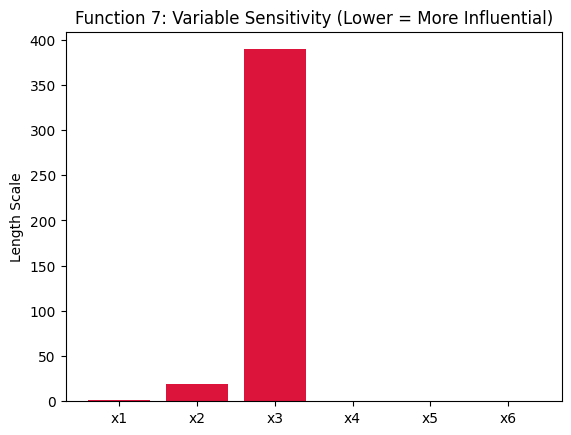

In [9]:
# A SHORTER bar means that variable is MORE IMPORTANT (the function changes fast there)
# A LONGER bar means that variable is NOISE (the function is flat there)
optimized_lengths = model.kernel_.get_params()['k1__length_scale']
plt.bar(['x1','x2','x3','x4','x5','x6'], optimized_lengths, color='crimson')
plt.title("Function 7: Variable Sensitivity (Lower = More Influential)")
plt.ylabel("Length Scale")
plt.show()

Therefore, we can see that currently x3 is making the least impact on the model, closely followed by x2.